<div style="text-align: center; padding-top: 12%;">

# Flavors of Gradient Descent

## DATA 301 @ WM

<figure class="no-fragment">
<center>
<a href="https://github.com/yanhai-xiong/DATA301-AML/blob/main/Module%203%20-%20Supervised%20Learning%20-%20Regression%20and%20Classification%20Problems/Section%201.2%20-%20Flavors_of_Gradient_Descent.ipynb" target="_blank">
    <img class="no-fragment"
         src="https://brand.github.com/_next/static/media/logo-03.cc5e5332.png"
         width="80px"/>
</a>
</center>
</figure>
</div>

We want to apply **gradient descent** to minimize the MSE, so we differentiate the MSE with respect to the model parameters.

# Practical Method to Include Bias

For a linear regression model, we usually include a **bias (intercept)** term and learn it together with the other model parameters: $\hat{y} = b + wx$, where $b$ is the bias (intercept).

**Practical Implementation: Add a Column of 1s**

For example, 
$\hat{y}_i = wx_i + b \rightarrow \hat{y}_i = wx_i + b x_i^0 $, $x_i^0 = 1$.

$$
\frac{\partial L}{\partial b}
=
-\frac{2}{N}
\sum_{i=1}^{N}
x_i^0
\left[y_i-\hat{y}_i\right]
$$

Now the **bias is just another weight**, and gradient descent can learn the weight and bias together using the same update procedure.

> **Note:** The column of 1s is used only to represent the bias and should **not** be standardized.




In practice, we simply add a **column of 1s** to the input data:
```python
X = np.column_stack((np.ones(len(x)), x))
```

We can treat the bias just like another weight by introducing a new feature that is always equal to 1. 
Now $b$ behaves just like another weight: $w$ multiplies the feature $x_i$, while $b$ multiplies the constant feature $x_i^0$. 
The gradient with respect to $b$ therefore has the same form as the gradient with respect to a weight.

## Why Standardize $x$?

The scale of the input features affects the scale of the gradients.
We commonly standardize each feature:
$$
x_j' = \frac{x_j-\mu_j}{\sigma_j}
$$

Standardization:
- puts features on comparable scales,
- usually makes gradient descent converge faster,
- makes the learning rate easier to choose,
- becomes especially important when features have very different scales.

> **Note:** Standardize the original features **before adding the bias column**. The column of 1s should **not** be standardized.

# Regularization

Consider predicting **Sales** using advertising spending:

$$
\widehat{Sales}
=
w_0
+
w_1 TV
+
w_2 Radio
+
w_3 Newspaper
$$

Ordinary Least Squares (OLS) chooses the coefficients that minimize the prediction error:

$$
MSE
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

A model may fit the training data using very large coefficients, making its predictions sensitive to particular features. Regularization penalizes large coefficients, encouraging a less sensitive model that may generalize better.

## **Regularization** with a penalty for large coefficients

$$
Loss
=
MSE
+
\lambda \times Penalty
$$

where $\lambda$ controls the strength of regularization.
- Small $\lambda$: coefficients stay closer to the OLS solution
- Large $\lambda$: coefficients are shrunk more strongly
- The intercept $w_0$ is usually **not regularized**

Regularization introduces some **bias** but can reduce **variance**, potentially improving performance on unseen data. Two common approaches are:
- **Ridge Regression:** L2 regularization
- **LASSO Regression:** L1 regularization

## Bias–Variance Tradeoff

Regularization shrinks the model coefficients, making the model less sensitive to the particular training data.

* **Bias:** systematic error from restricting the model too much
* **Variance:** how much the learned model changes across different training samples

Increasing regularization typically:

$$
\text{Bias} \uparrow
\qquad
\text{Variance} \downarrow
$$

Although training error may increase, the model may perform **better on unseen data**.

> **Goal:** Find a balance between fitting the training data and generalizing to new data.


## Ridge Regression — L2 Regularization

For the Advertising model, Ridge Regression discourages large coefficients and minimizes:
$$
L_{Ridge}
=
MSE
+
\lambda
\sum_{j=1}^{p}w_j^2
$$


For Ridge, the gradient contains an additional term:
$$
\frac{\partial L_{Ridge}}{\partial w_j}
=
\frac{\partial MSE}{\partial w_j}
+
2\lambda w_j
$$

Therefore, the gradient descent update becomes:
$$
w_j
\leftarrow
w_j
-
\eta
\left(
\frac{\partial MSE}{\partial w_j}
+
2\lambda w_j
\right)
$$

The extra term continuously pushes the coefficients toward zero.

**Ridge shrinks coefficients toward zero, but usually does not make them exactly zero.**

## LASSO Regression — L1 Regularization

LASSO uses the absolute values of the coefficients as the penalty.
$$
L_{LASSO}
=
MSE
+
\lambda
\sum_{j=1}^{p}|w_j|
$$

Therefore, the gradient descent update becomes:
$$
w_j
\leftarrow
w_j
-
\eta
\left(
\frac{\partial MSE}{\partial w_j}
+
\lambda \text{sign}(w_j)
\right)
$$

LASSO can shrink some coefficients **exactly to zero** and perform **feature selection** automatically. In practice, LASSO is often optimized using methods such as coordinate descent or proximal gradient descent because LASSO is not differentiable at zero.

## <font color='blue' size=5pt>Elastic Net Regression</font>

**Elastic Net** combines **L1 (Lasso)** and **L2 (Ridge)** regularization:

$$
\large
L(w)
=
\underbrace{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}_{\text{MSE}}
+
\underbrace{\alpha_1\sum_{j=1}^{p}|w_j|}_{\text{L1: Lasso}}
+
\underbrace{\alpha_2\sum_{j=1}^{p}w_j^2}_{\text{L2: Ridge}}
$$

where the **bias term $w_0$ is typically not regularized**.

<font color='green'>Why combine Lasso and Ridge?</font>

- **Lasso (L1)** can shrink some coefficients exactly to **zero** → feature selection.
- **Ridge (L2)** shrinks coefficients toward zero and is useful when features are **highly correlated**.
- **Elastic Net** combines both effects → it can perform feature selection while handling correlated features more stably than Lasso alone.


A common alternative parameterization is:

$$
\large
L(w)
=
\text{MSE}
+
\alpha
\left[
\rho\sum_{j=1}^{p}|w_j|
+
(1-\rho)\sum_{j=1}^{p}w_j^2
\right]
$$

where:

- $\alpha$ controls the **overall strength of regularization**.
- $\rho$ controls the **mixture of L1 and L2 penalties**.

$$
\begin{aligned}
\rho = 1 &\Rightarrow \text{Lasso} \\
\rho = 0 &\Rightarrow \text{Ridge} \\
0 < \rho < 1 &\Rightarrow \text{Elastic Net}
\end{aligned}
$$

> **Key idea:** Elastic Net provides a compromise between the **sparsity of Lasso** and the **stability of Ridge**.

## Ridge vs. LASSO vs. Elastic Net

| | Ridge | LASSO | Elastic Net |
|---|---|---|---|
| **Regularization** | L2 | L1 | L1 + L2 |
| **Penalty** | Sum of squared coefficients | Sum of absolute coefficients | Combination of both |
| **Shrinks coefficients** | Yes | Yes | Yes |
| **Coefficients exactly zero** | Usually no | Possible | Possible |
| **Feature selection** | No | Yes | Yes |
| **Correlated features** | Tends to keep them together | May select one and discard others | Can keep/select groups of correlated features |
| **Best suited for** | Many small/moderate effects | Sparse models | Sparse models with correlated features |

### <font color='green'>Key Takeaway</font>

- **Ridge:** shrink coefficients, but usually keep **all features**.
- **LASSO:** shrink coefficients and can **remove features**.
- **Elastic Net:** combines the strengths of **Ridge + LASSO**.

> **Important:** Because the L1 penalty $|w_j|$ is not differentiable at $w_j=0$, LASSO and Elastic Net require slightly different optimization treatment than ordinary gradient descent. We focus here on their effects on the learned model.

# <font color='blue' size=6pt>Gradient Descent Optimization Methods</font>

Gradient descent methods differ mainly in:

1. **How much data is used to compute each gradient**
2. **How the gradient and learning rate are adjusted over time**

Let $w_t$ denote the weights at step $t$, $g_t$ the gradient, and $\eta$ the learning rate:

$$
w_t = w_{t-1}-\eta g_t
$$

## <font color='blue' size=5pt>Batch Gradient Descent (BGD)</font>

**Batch Gradient Descent** computes the gradient using the **entire training dataset**:

$$
g_t=
\frac{1}{N}
\sum_{i=1}^{N}
\nabla_w L_i(w_{t-1})
$$

$$
w_t=w_{t-1}-\eta g_t
$$

* Stable and accurate gradient
* Each update can be expensive for large datasets
* **One update per epoch**

## <font color='blue' size=5pt>Stochastic Gradient Descent (SGD)</font>

**SGD** randomly selects **one training observation** for each update:

$$
g_t=\nabla_w L_i(w_{t-1})
$$

$$
w_t=w_{t-1}-\eta g_t
$$

* Very inexpensive updates
* Many updates per epoch
* Gradient is noisy and the loss may fluctuate

The noise can help SGD move through flat regions, but it can also cause the weights to oscillate around a minimum.

## <font color='blue' size=5pt>Mini-Batch Gradient Descent</font>

In practice, we usually use a **mini-batch** of observations:

$$
g_t=
\frac{1}{|B_t|}
\sum_{i\in B_t}
\nabla_w L_i(w_{t-1})
$$

$$
w_t=w_{t-1}-\eta g_t
$$

where $B_t$ is the mini-batch used at step $t$.

| Method     | Data per Update  | Gradient       |
| ---------- | ---------------- | -------------- |
| BGD        | All observations | Stable         |
| SGD        | 1 observation    | Noisy          |
| Mini-batch | Small batch      | Moderate noise |

> **Mini-batch gradient descent is the standard approach for training modern neural networks.**

# <font color='blue' size=6pt>Improving Gradient Descent</font>

Even with mini-batches, basic gradient descent can be slow, oscillate, or be sensitive to the learning rate.

Modern optimizers modify the basic update:

$$
w_t=w_{t-1}-\eta_t v_t
$$

where $\eta_t$ may be an adaptive learning rate and $v_t$ may be a modified gradient.

## <font color='blue' size=5pt>Learning Rate Scheduling</font>

Instead of keeping the learning rate fixed, we can reduce it during training.

For example, exponential decay:

$$
\eta_t=\eta_0e^{-\lambda t}
$$

or polynomial decay:

$$
\eta_t=\eta_0(\beta t+1)^{-\alpha}
$$

> **Idea:** take larger steps early and smaller steps as training approaches a minimum.

## <font color='blue' size=5pt>Momentum</font>

Momentum combines the current gradient with previous update directions:

$$
v_t=\beta v_{t-1}+(1-\beta)g_t
$$

$$
w_t=w_{t-1}-\eta v_t
$$

where $\beta$ controls how much past gradients influence the current update.

> **Idea:** build momentum in consistent directions while reducing oscillations.

## <font color='blue' size=5pt>AdaGrad</font>

AdaGrad keeps track of the accumulated squared gradients:

$$
s_t=s_{t-1}+g_t^2
$$

and updates:

$$
w_t=
w_{t-1}
-
\frac{\eta}{\sqrt{s_t}+\epsilon}g_t
$$

>**Idea:** parameters with large historical gradients receive smaller future updates.

**Limitation:** $s_t$ continually increases, so the effective learning rate can eventually become very small.

## <font color='blue' size=5pt>RMSProp</font>

RMSProp addresses AdaGrad's continually decreasing learning rate by using an **exponential moving average** of squared gradients:

$$
s_t=\gamma s_{t-1}+(1-\gamma)g_t^2
$$

$$
w_t=
w_{t-1}
-
\frac{\eta}{\sqrt{s_t}+\epsilon}g_t
$$

>**Idea:** adapt the learning rate using **recent** squared gradients rather than all past gradients.

## <font color='blue' size=5pt>Adam</font>

**Adam = Momentum + RMSProp**

Adam maintains an exponential moving average of both the gradients and squared gradients:

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

Because both are initialized at zero, Adam applies bias correction:

$$
\hat{m}_t=\frac{m_t}{1-\beta_1^t},
\hat{v}_t=\frac{v_t}{1-\beta_2^t}
$$

The weights are then updated using:

$$
w_t=
w_{t-1}
-
\eta
\frac{\hat{m}_t}
{\sqrt{\hat{v}_t}+\epsilon}
$$

> **Adam combines momentum with an adaptive learning rate for each parameter.**

## <font color='blue' size=5pt>Summary</font>

$$
\text{BGD}
\rightarrow
\text{SGD}
\rightarrow
\text{Mini-Batch}
\rightarrow
\text{Momentum}
\rightarrow
\text{AdaGrad/RMSProp}
\rightarrow
\text{Adam}
$$

| Method         | Main Idea                           | When to Use |
| -------------- | ----------------------------------- | ----------- |
| **BGD**        | Use all training data               | Small datasets; stable and accurate gradients |
| **SGD**        | Use one observation                 | Very large or streaming datasets; fast updates |
| **Mini-batch** | Use a small batch                   | Most large-scale ML/deep learning; efficient GPU computation |
| **Momentum**   | Use past gradient directions        | Noisy gradients, oscillations, or slow convergence |
| **AdaGrad**    | Accumulate squared gradients        | Sparse features; parameters updated at different frequencies |
| **RMSProp**    | Moving average of squared gradients | Non-stationary/noisy objectives; deep learning |
| **Adam**       | Momentum + adaptive learning rates  | Good general-purpose default for deep learning |

# Coding

In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/yanhaixiong/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/yanhaixiong/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/yanhaixiong/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.start()
  

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/yanhaixiong/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/yanhaixiong/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/yanhaixiong/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.start()
  

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/yanhaixiong/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/yanhaixiong/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/yanhaixiong/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.start()
  

AttributeError: _ARRAY_API not found

## RIDGE

In [2]:
# get some real data to play with for gradient descent
data = pd.read_csv('https://github.com/yanhai-xiong/DATA301-AML/blob/main/Data%20Sets/Advertising.csv?raw=true')

In [3]:
data.head(5)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# here the goal is to predict the Sales (cont. variable) by using values from TV, Radio and Newspaper advertising
x = data.loc[:,['TV','Radio','Newspaper']].values
y = data['Sales'].values

In [5]:
# first we want to center the data, and then we want to find the optimal weights for a linear model, i.e. minimize the sum of squared errors
# we may need a scaler
def zscore(x):
    return (x-np.mean(x,axis=0))/np.std(x,axis=0)

In [6]:
xscaled = zscore(x)

In [7]:
# let's repeat the gradient descent by including a bias term and by NOT centereing the values of y
x_aug = np.column_stack([np.ones(len(xscaled)),xscaled])

In [8]:
def L_ridge(x_aug,w):
    prediction = x_aug@w 
    errors = y - prediction
    return sum((errors**2))/len(errors) + alpha*sum(w**2)

In [9]:
def gradient_ridge(x_aug,w):
    prediction = x_aug@w
    errors = y - prediction
    return (-2/len(errors))*errors@x_aug + 2*alpha*np.array(w)

In [10]:
def gradient(x_aug, w):
    prediction = x_aug@w
    errors = y - prediction
    return (-1/len(errors))*errors@x_aug # here we applied the Chain Rule to differentiate; also the linear algebra behind matrix-vector products

In [16]:
# we look for the optimal weights w1, w2 and w3 such that the predictions made with the corresponding linear combination of the columns is minimizing SSE
# define the loss function
# if we use ycentered we do not need an intercept term 
def L(x_aug, w):
    prediction = x_aug@w
    errors = y - prediction
    return sum((errors**2))/len(errors) # this is MSE

In [21]:
# apply GD for training the Ridge coefficients
# we want the "optimal" value for the weights
maxiter = 2000
learning_rate = 0.01
# we want some stopping criteria, for example if the weights are no longer significantly updated
# we measure the difference between w_new and w_old vs epsilon -> tolerance for deciding convergence.
tol = 1e-6
w_old = [0,1,2,3]
alpha = 0.01

In [22]:
# how to implement the gradient descent
for it in range(maxiter):
    w_new = w_old - learning_rate*gradient_ridge(x_aug, w_old)

    if max(abs(w_new-w_old))<tol:
        print("The algorithm has converged!")
        break

    w_old = w_new
    if (it+1)%100==0:
        print('Iteration', it+1, 'The MSE is : '+str(L(x_aug, w_old)))

Iteration 100 The MSE is : 7.1249749225194785
Iteration 200 The MSE is : 2.9636717336388965
Iteration 300 The MSE is : 2.8193454219648375
Iteration 400 The MSE is : 2.8075472519589715
Iteration 500 The MSE is : 2.806010086017798
Iteration 600 The MSE is : 2.8057644119668
Iteration 700 The MSE is : 2.8057185295218465
The algorithm has converged!


## The Mini_Batch Stochastic Gradient Descent

Not getting stuck in a sub-optimal local minima!

In [23]:
# step one shuffle the data (randomly permute the order of observations)
# step two split it in mini-batches (subsets of pretty much the same cardinality)
# for updating the weights we only use gradients computed on the mini-batches
####################################

# step 1:
ind = np.random.permutation(range(len(x)))
batches = np.array_split(ind,10)

In [25]:
print(batches[0], len(batches[0]))

[ 34 125 185 176  77  85  88  93   0  29 109  30 119  82 192  60 114 158
 144  81] 20


In [26]:
def gradient(w, ind):
    prediction = x_aug[ind]@w
    errors = y[ind] - prediction
    return (-2/len(errors))*errors@x_aug[ind]

In [47]:
# we want the "optimal" value for the weights
epochs = 2000*20
batch_size = 12
learning_rate = 0.01
# we want some stopping criteria, for example if the weights are no longer significantly updated
# we measure the difference between w_new and w_old vs epsilon -> tolerance for deciding convergence.
tol = 1e-5
w_old = [0,1,2,3]
done = False

In [48]:
# how to implement the gradient descent
for epoch in range(epochs):
    ind = np.random.permutation(range(len(x)))
    batches = np.array_split(ind,batch_size)
    for ind in batches:
        w_new = w_old - learning_rate*gradient(w_old,ind)
    
        if max(abs(w_new-w_old))<tol:
            done = True
            break
    
        w_old = w_new
    if (epoch+1)%4000==0:
        print('Iteration', epoch+1, 'The MSE is : '+str(L(x_aug, w_old)))
    if done:
        print("The algorithm has converged!")
        break

Iteration 4000 The MSE is : 2.7842636389939317
Iteration 8000 The MSE is : 2.784156014966119
Iteration 12000 The MSE is : 2.7842227856108877
Iteration 16000 The MSE is : 2.78425982579055
Iteration 20000 The MSE is : 2.784397393650494
Iteration 24000 The MSE is : 2.7842480796177536
Iteration 28000 The MSE is : 2.7843619447485497
Iteration 32000 The MSE is : 2.7841837020128857
Iteration 36000 The MSE is : 2.7843564102478786
Iteration 40000 The MSE is : 2.7841802369719137


## Mini-Batch Stochastic Adaptive Gradient Descent AdaGrad

In [49]:
# we want the "optimal" value for the weights
epochs = 5000
batch_size = 10
learning_rate = 0.05
# we want some stopping criteria, for example if the weights are no longer significantly updated
# we measure the difference between w_new and w_old vs epsilon -> tolerance for deciding convergence.
tol = 1e-6
w_old = [0,1,2,3]
done = False
eta = 1
epsilon = 1e-6
s = 0

In [50]:
# how to implement the mini-batch adaptive gradient descent
for epoch in range(epochs):
    ind = np.random.permutation(range(len(x)))
    batches = np.array_split(ind,len(x)//batch_size)
    for ind in batches:
        g = gradient(w_old,ind)
        s += sum(g**2)
        learning_rate = eta/np.sqrt(s+epsilon)
        w_new = w_old - learning_rate*g
    
        if max(abs(w_new-w_old))<tol:
            done = True
            break
    
        w_old = w_new
    if (epoch+1)%1000==0:
        print('Iteration', epoch+1, 'The MSE is : '+str(L(x_aug, w_old)))
    if done:
        print("The algorithm has converged!")
        break

Iteration 1000 The MSE is : 2.7841294970398116
Iteration 2000 The MSE is : 2.78412828771434
Iteration 3000 The MSE is : 2.78412942666923
Iteration 4000 The MSE is : 2.78412770519404
Iteration 5000 The MSE is : 2.7841267492068766


## Root Mean Square Propagation RMSProp

In [53]:
# we want the "optimal" value for the weights
epochs = 10000
batch_size = 100
# we want some stopping criteria, for example if the weights are no longer significantly updated
# we measure the difference between w_new and w_old vs epsilon -> tolerance for deciding convergence.
tol = 1e-5
w_old = [0,1,2,3]
done = False
eta = 0.001
epsilon = 1e-8
s = 0
gamma = 0.9

In [54]:
# how to implement the mini-batch adaptive gradient descent
for epoch in range(epochs):
    ind = np.random.permutation(range(len(x)))
    batches = np.array_split(ind,len(x)//batch_size)
    for ind in batches:
        g = gradient(w_old,ind)
        s = gamma*s +(1-gamma)*sum(g**2)
        learning_rate = eta/np.sqrt(s+epsilon)
        w_new = w_old - learning_rate*g
    
        if max(abs(w_new-w_old))<tol:
            done = True
            break
    
        w_old = w_new
    if (epoch+1)%1000==0:
        print('Iteration', epoch+1, 'The MSE is : '+str(L(x_aug, w_old)))
    if done:
        print("The algorithm has converged!")
        break

Iteration 1000 The MSE is : 161.28748311196838
Iteration 2000 The MSE is : 115.43466248740228
Iteration 3000 The MSE is : 77.43300891956395
Iteration 4000 The MSE is : 47.260594764282956
Iteration 5000 The MSE is : 24.90768699796853
Iteration 6000 The MSE is : 10.339851259282545
Iteration 7000 The MSE is : 3.489782199818815
Iteration 8000 The MSE is : 2.78421059734212
Iteration 9000 The MSE is : 2.784126479963707
Iteration 10000 The MSE is : 2.7841263942056895


## Visualization Comparison of GD Algorithms

In [55]:
def Visualize_F(f, bounds):
    #Create the figure
    fig = plt.figure(figsize=(15, 10))
    
    #Create grid of evaluation points in the bounds
    grid = np.meshgrid(np.linspace(bounds[0][0], bounds[0][1], 200), np.linspace(bounds[1][0], bounds[1][1], 200))
    
    #Evaluate the function on the grid and plot the contour
    cp = plt.contour(grid[0], grid[1], f(grid[0], grid[1]), levels=20, cmap='coolwarm')
    plt.clabel(cp, inline=1, fontsize=12)
    #Setup the colorbar for showing f values
    plt.colorbar(label='f(x,y)')
    
    #Formatting
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Contour plot of f(x,y)')
    return fig

In [56]:
# Parameters
width, height = 1920, 1200
nx, ny = width // 5, height // 5
h = 1e-7


domain_x = np.linspace(-2, 2, nx)
domain_y = np.linspace(-2, 2, ny)
X, Y = np.meshgrid(domain_x, domain_y)

# Function definitions
def f(x, y):
    return (-2 * np.exp(-((x - 1) ** 2 + y ** 2) / 0.2) +
            -3 * np.exp(-((x + 1) ** 2 + y ** 2) / 0.2) +
            x ** 2 + y ** 2)

def grad_f(x, y):
    grad_x = (f(x + h, y) - f(x, y)) / h
    grad_y = (f(x, y + h) - f(x, y)) / h
    return np.array([grad_x, grad_y])

Z = f(X, Y)

# Optimizers
def get_gd_path(x0, y0, learning_rate, num_steps):
    path = np.zeros((num_steps, 2))
    path[0] = np.array([x0, y0])
    for i in range(1, num_steps):
        grad = grad_f(*path[i-1])
        path[i] = path[i-1] - learning_rate * grad
    return path

def get_momentum_path(x0, y0, learning_rate, num_steps, momentum):
    path = np.zeros((num_steps, 2))
    path[0] = np.array([x0, y0])
    velocity = np.zeros(2)
    for i in range(1, num_steps):
        grad = grad_f(*path[i-1])
        velocity = momentum * velocity - learning_rate * grad
        path[i] = path[i-1] + velocity
    return path

def get_rmsprop_path(x0, y0, learning_rate, num_steps, decay_rate, eps):
    path = np.zeros((num_steps, 2))
    path[0] = np.array([x0, y0])
    cache = np.zeros(2)
    for i in range(1, num_steps):
        grad = grad_f(*path[i-1])
        cache = decay_rate * cache + (1 - decay_rate) * grad**2
        path[i] = path[i-1] - learning_rate * grad / (np.sqrt(cache) + eps)
    return path

def get_adam_path(x0, y0, learning_rate, num_steps, beta_1, beta_2, eps):
    path = np.zeros((num_steps, 2))
    path[0] = np.array([x0, y0])
    m, v = np.zeros(2), np.zeros(2)
    for i in range(1, num_steps):
        grad = grad_f(*path[i-1])
        m = beta_1 * m + (1 - beta_1) * grad
        v = beta_2 * v + (1 - beta_2) * grad**2
        m_hat = m / (1 - beta_1**(i+1))
        v_hat = v / (1 - beta_2**(i+1))
        path[i] = path[i-1] - learning_rate * m_hat / (np.sqrt(v_hat) + eps)
    return path

# Generate paths

def gen_paths(x0,y0):
  gd_path = get_gd_path(x0, y0, 0.02, 500)
  momentum_path = get_momentum_path(x0, y0, 0.01, 200, 0.8)
  rmsprop_path = get_rmsprop_path(x0, y0, 0.01, 300, 0.99, 1e-6)
  adam_path = get_adam_path(x0, y0, 0.01, 500, 0.7, 0.999, 1e-6)

  # Plotting
  fig = make_subplots(rows=1, cols=1, subplot_titles=("Contour Plot and Optimization Paths",))

  fig.add_trace(go.Contour(
      z=Z,
      x=domain_x,
      y=domain_y,
      contours=dict(
          coloring='heatmap',
          showlabels=True,
          labelfont=dict(size=12, color='white', family='Arial')
      ),
      colorbar=dict(title="Function value")
  ), row=1, col=1)

  fig.add_trace(go.Scatter(
      x=gd_path[:, 0], y=gd_path[:, 1],
      mode='lines+markers',
      name='SGD',
      line=dict(color='black')
  ), row=1, col=1)

  fig.add_trace(go.Scatter(
      x=momentum_path[:, 0], y=momentum_path[:, 1],
      mode='lines+markers',
      name='Momentum',
      line=dict(color='blue')
  ), row=1, col=1)

  fig.add_trace(go.Scatter(
      x=rmsprop_path[:, 0], y=rmsprop_path[:, 1],
      mode='lines+markers',
      name='RMSProp',
      line=dict(color='red')
  ), row=1, col=1)

  fig.add_trace(go.Scatter(
      x=adam_path[:, 0], y=adam_path[:, 1],
      mode='lines+markers',
      name='Adam',
      line=dict(color='green')
  ), row=1, col=1)

  fig.update_layout(
      title="Optimization Path Visualizations",
      xaxis_title="X-axis",
      yaxis_title="Y-axis",
      legend=dict(x=0.1, y=0.9)
  )

  fig.show()


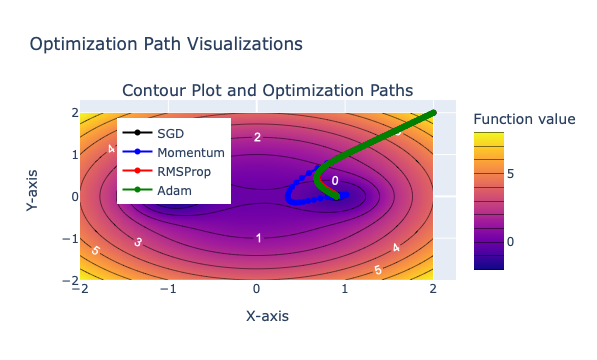

In [59]:
gen_paths(2,2)

In [60]:
path = get_adam_path(1, 1.75, 0.01, 500, 0.7, 0.999, 1e-6)

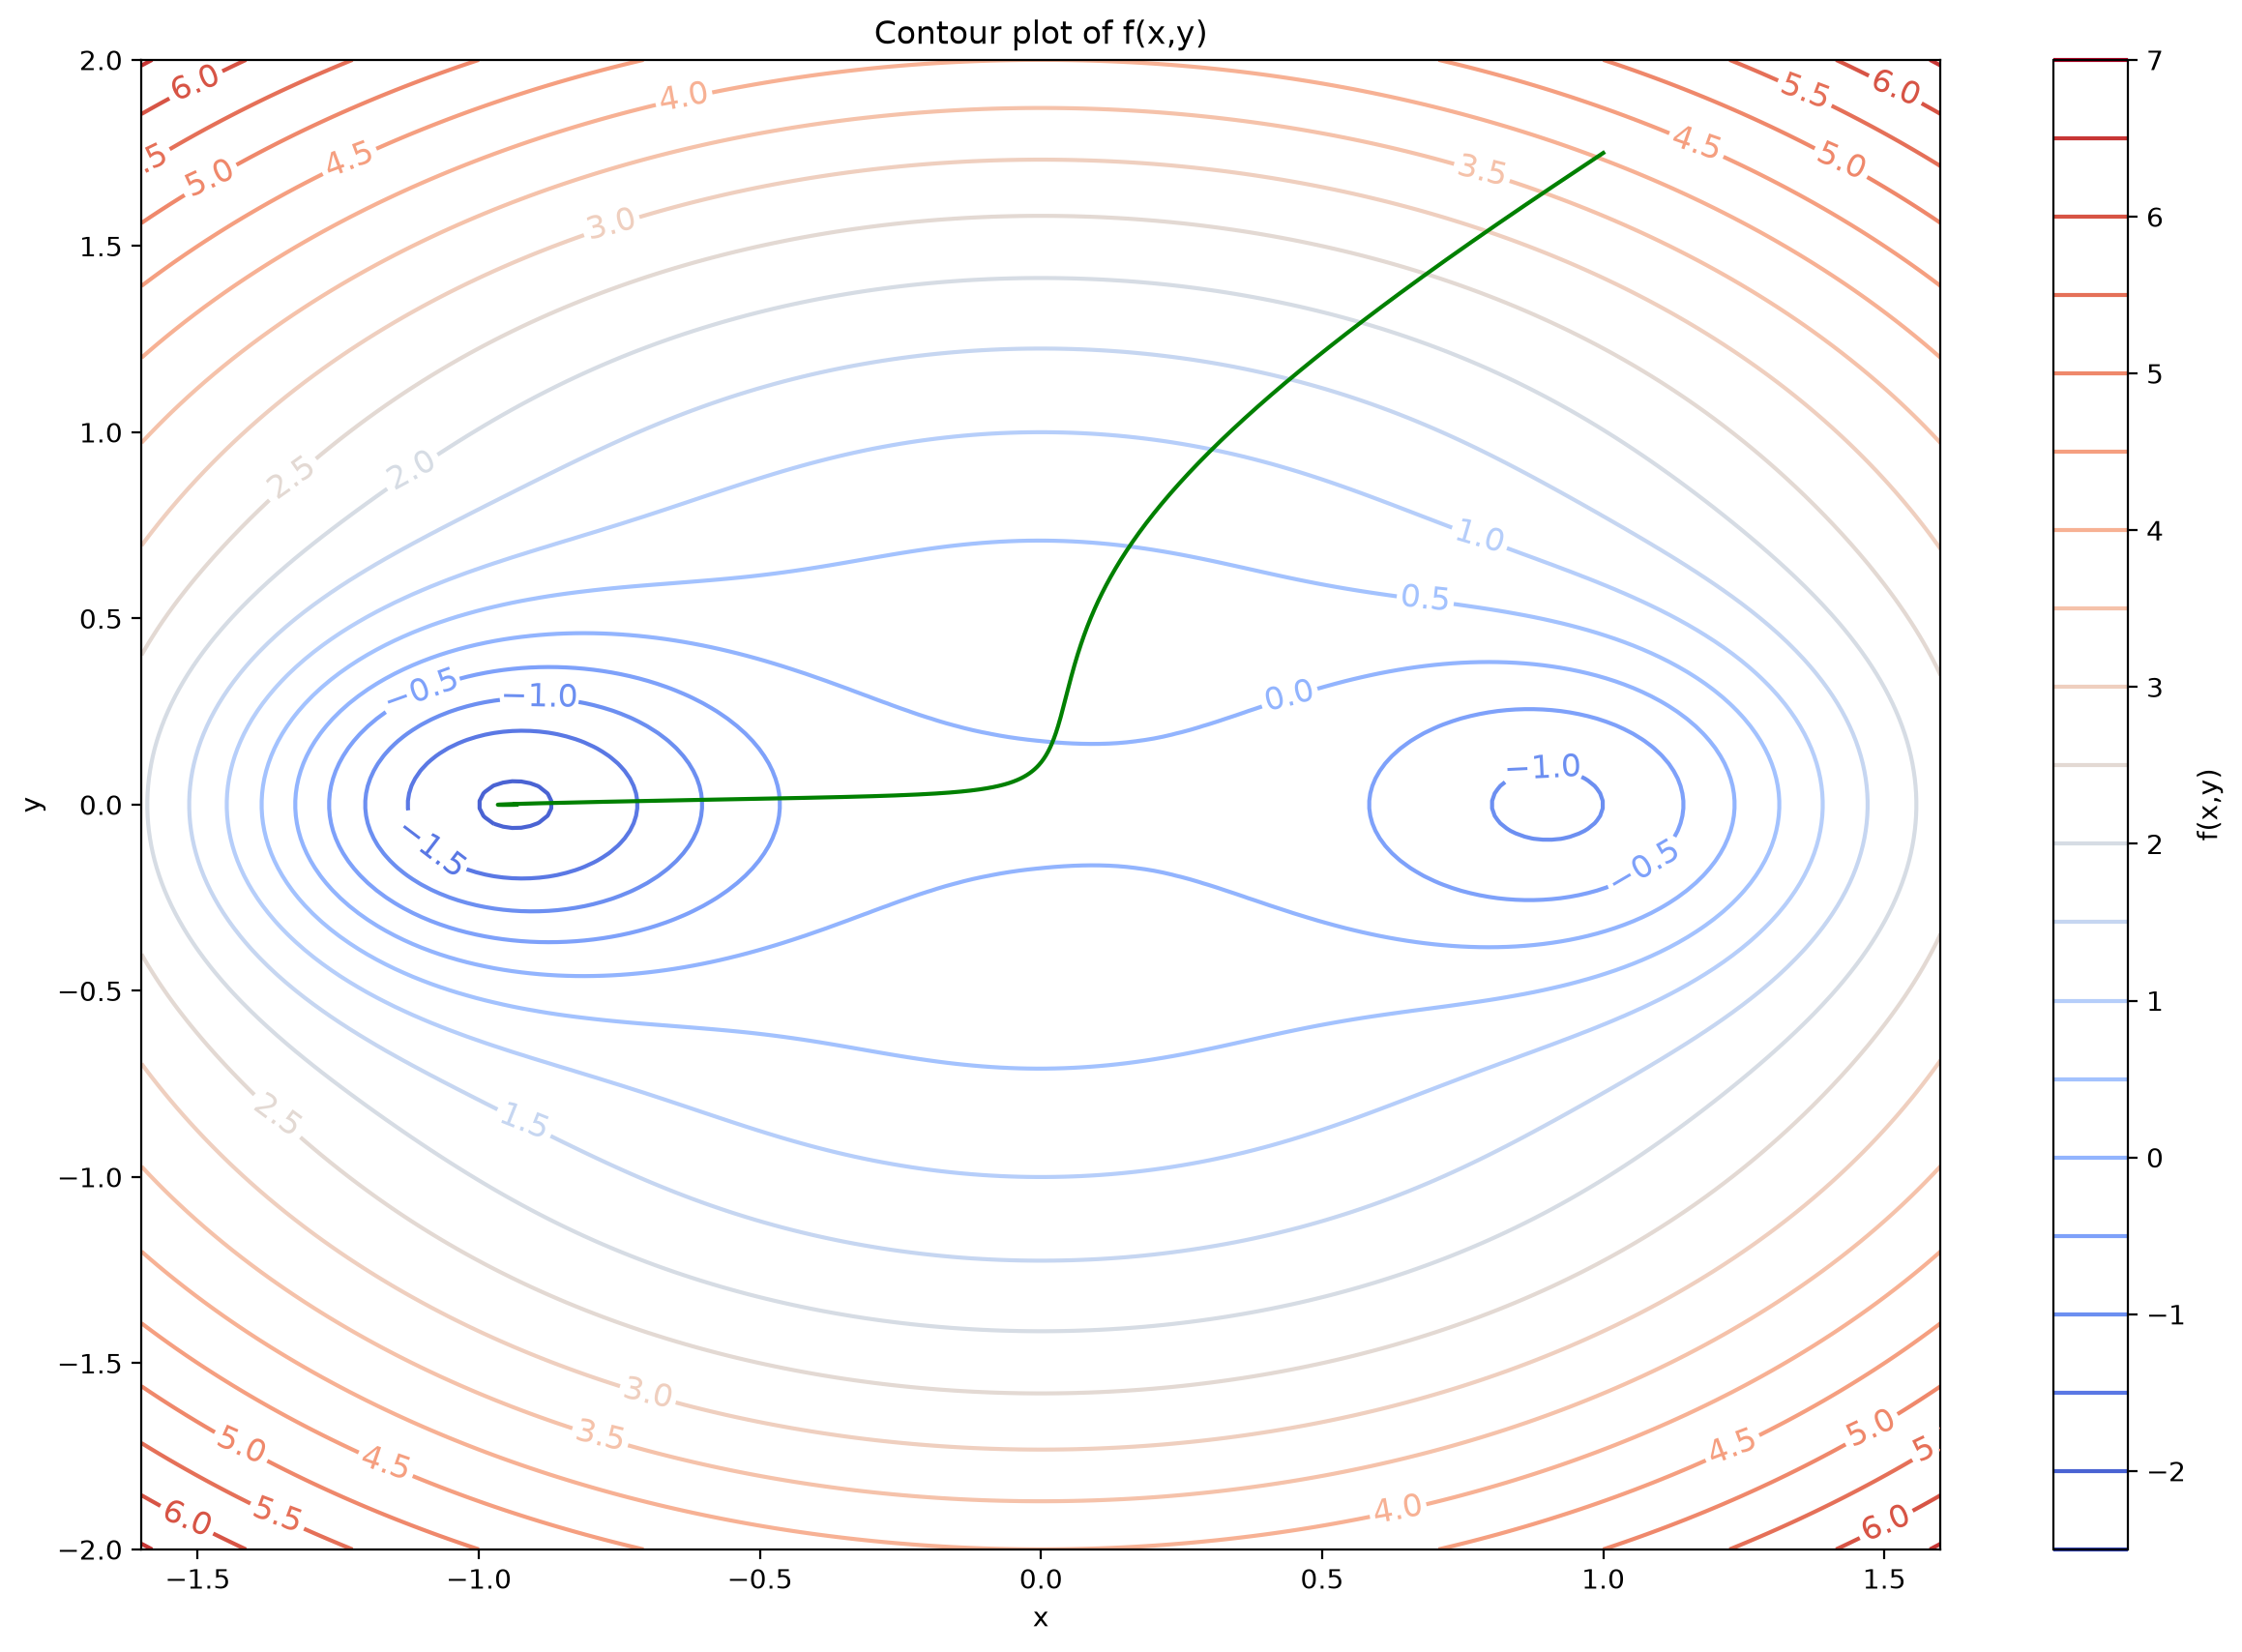

In [61]:
fig = Visualize_F(f,[(-1.6,1.6),(-2,2)])
plt.plot(path[:,0],path[:,1],color='green')

In [62]:
gd_path = get_gd_path(1.3, 0.5, 0.02, 500)

In [63]:
gd_path[0][:]

array([1.3, 0.5])

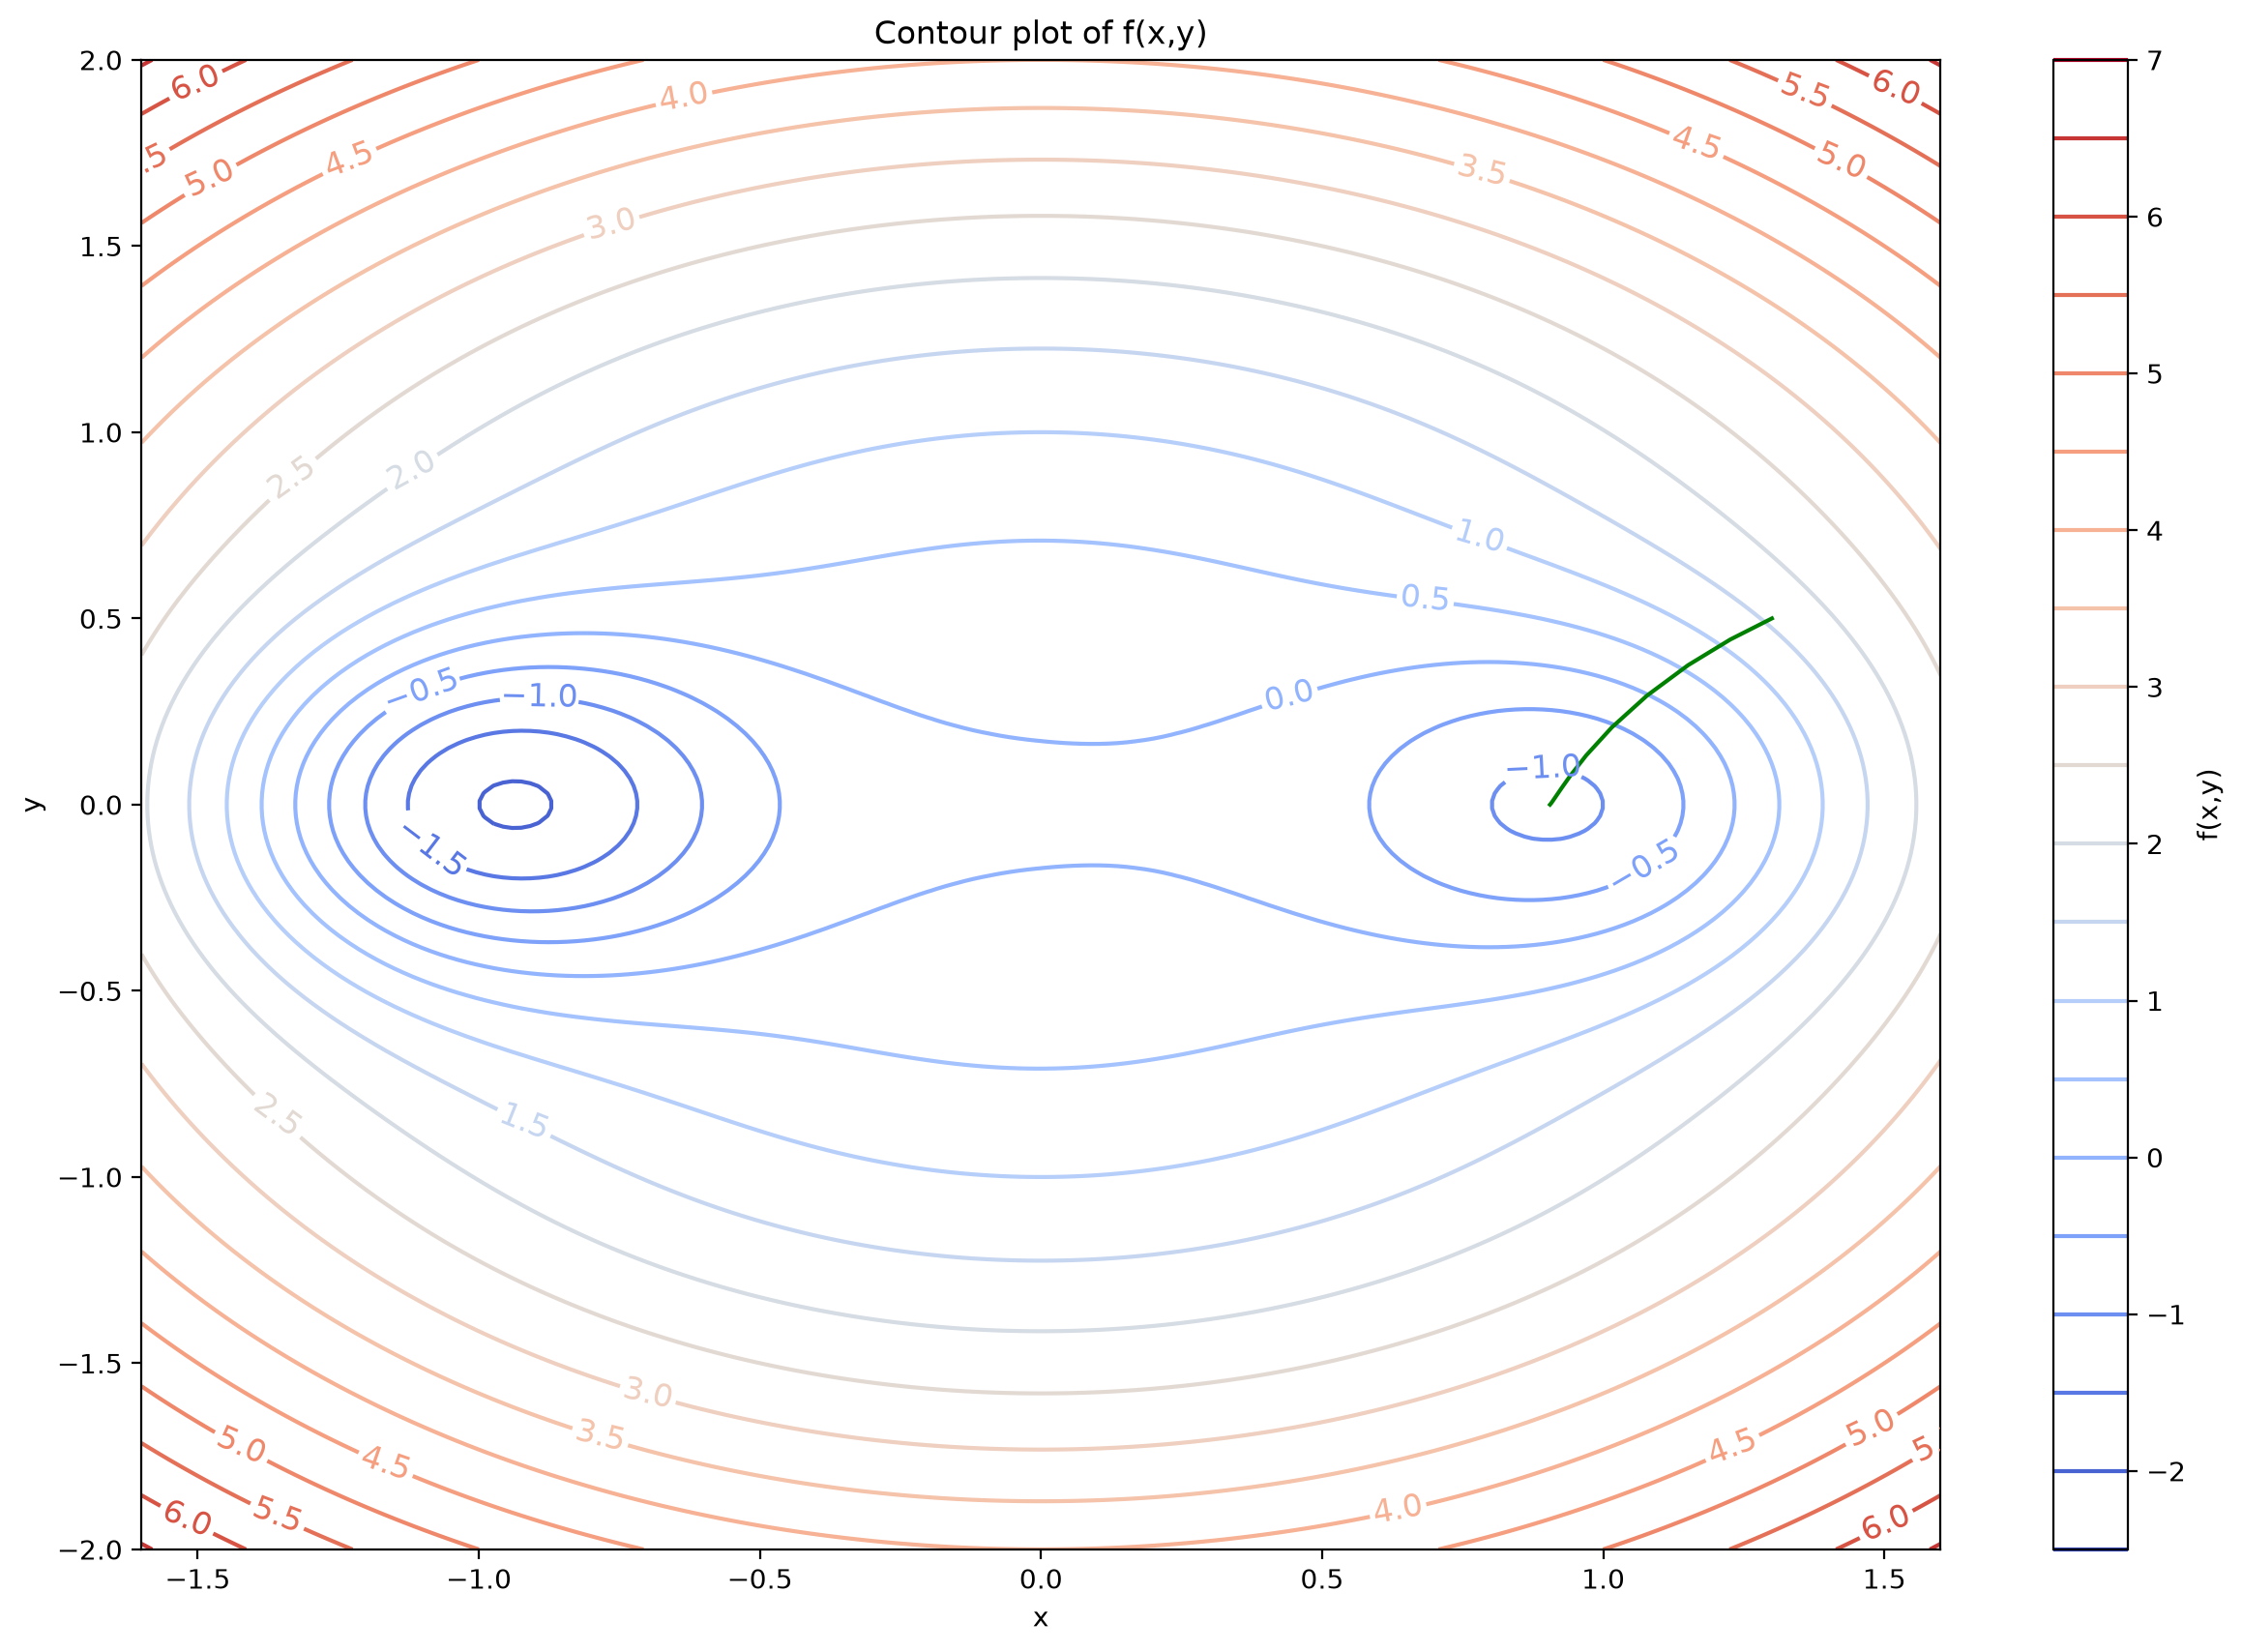

In [65]:
fig = Visualize_F(f,[(-1.6,1.6),(-2,2)])
plt.plot(gd_path[:,0],gd_path[:,1],color='green')

# Active Coding

1. Can you update the RIDGE implementation to make it only regularize non-bias parameters?
1. Write your own code to implement **mini-batch stochastic gradient descent using the Adam optimizer**.
    1. Shuffle the observations at the beginning of each epoch.
    2. Divide the observations into mini-batches.
    3. Compute the gradient using each mini-batch.
    4. Maintain the first-moment estimate $m_t$.
    5. Maintain the second-moment estimate $v_t$.
    6. Apply bias correction to obtain $\hat m_t$ and $\hat v_t$.
    7. Update the model parameters using Adam.
    8. Monitor the MSE on the **whole training set** after each epoch.